In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
import statistics as stat

In [2]:
path = '2018-12-07_DIC/'
date = '2018-12-07'
ch = ['22','23','31','32','33']
conc_name = ['10','15','7-5','12-5','20']
conc = [10,15,7.5,12.5,20]
intr = [10,10,10,10,10]

In [3]:
k=1
filename = path+date+'_CH'+ch[k]+'_'+conc_name[k]+'uM'
    
data = pd.read_csv(filename+'.csv',sep=',');
oddID = [n for n in data['Track ID'] if (n+1)%2]

#for i in oddID:
 #   print(i);
supp = pd.read_csv(filename+'_start.csv',sep=',');
    
evenID = [n for n in data['Track ID'] if (n+1)%2]
    
y1 = []

l = evenID[3]
data['Track ID'][0]

1

In [5]:
def dynamics(k):
    
    filename = path+date+'_CH'+ch[k]+'_'+conc_name[k]+'uM'
    
    data = pd.read_csv(filename+'.csv',sep=',');
    supp = pd.read_csv(filename+'_start.csv',sep=',');
    
    inter = intr[k];
    
    n = len(supp['Track ID'])
    start = sum(supp['Track duration (s)'])/n;
    
    ####################################
    
    oddID = [n-1 for n in data['Track ID'] if n%2]
    speed = []
    
    for i in oddID:
        s = abs(data['Track speed (um/s)'][i])*60;
        speed = np.append(speed,s)
    
    Mspeed = stat.mean(speed)
    Sspeed = stat.stdev(speed)
    
    ####################################
    
    evenID = [n for n in data['Track ID'] if n%2]
    
    y1 = []
    duration = []
    
    for i in evenID:
        y1 = np.append(y1,min(data['y1'][i],data['y2'][i]))
        y2 = max(data['y1'][i],data['y2'][i])
        
        if y2 < 119:
            dur = (data['Track duration (s)'][i]);
            duration = np.append(duration,dur/60)
    
    track_start = (y1*inter - start)/60;
    
    Mnuc = stat.mean(track_start)
    Snuc = stat.stdev(track_start)
    track_start.sort()
    
    Mdur = stat.mean(duration)
    Sdur = stat.stdev(duration)
    duration.sort()
    
    return Mspeed, Sspeed, Mnuc, Snuc, Mdur, Sdur, track_start, duration

In [11]:
m_speed = []
s_speed = []

m_nuc = []
s_nuc = []

m_dur = []
s_dur = []

for i in range(0,len(ch)):
    
    track = dynamics(i)
    
    m_speed = np.append(m_speed,track[0])
    s_speed = np.append(s_speed,track[1])
    
    m_nuc = np.append(m_nuc,track[2])
    s_nuc = np.append(s_nuc,track[3])
    
    m_dur = np.append(m_dur,track[4])
    s_dur = np.append(s_dur,track[5])

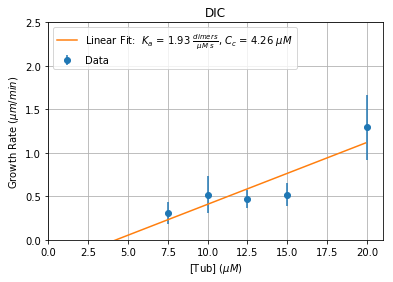

In [12]:
a1 , a0 = np.polyfit(conc, m_speed, 1)
y_int = -a0/a1
x_range = np.arange(0,20,0.1)

plt.errorbar(conc,m_speed, yerr=s_speed, fmt='o')
plt.plot(x_range, a1*x_range+a0)
plt.legend(('Linear Fit:  'r'$K_a$'' = %.2f 'r'$\frac{dimers}{\mu M \; s}$'', 'r'$C_c$'' = %.2f 'r'$\mu M$' %(a1*27.1, y_int),'Data'),loc='upper left')
plt.xlabel('[Tub] ' r'$(\mu M)$')
plt.ylabel('Growth Rate ' r'$(\mu m / min)$')
plt.ylim(0,2.5)
plt.xlim(0,21)
plt.grid(True)
plt.title('DIC');

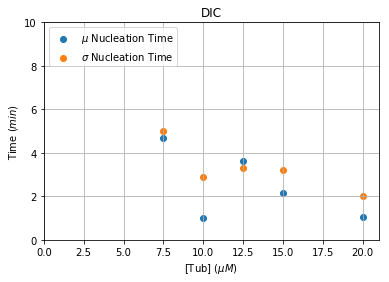

In [13]:
plt.scatter(conc,m_nuc)
plt.scatter(conc,s_nuc)
plt.legend(( r'$\mu$' ' Nucleation Time',r'$\sigma$' ' Nucleation Time'),loc='upper left')
plt.xlabel('[Tub] ' r'$(\mu M)$')
plt.ylabel('Time ' r'$(min)$')
plt.ylim(0,10)
plt.xlim(0,21)
plt.grid(True)
plt.title('DIC');

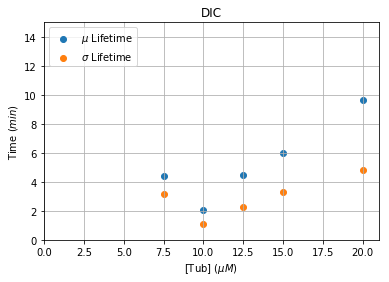

In [14]:
plt.scatter(conc,m_dur)
plt.scatter(conc,s_dur)
plt.legend(( r'$\mu$' ' Lifetime',r'$\sigma$' ' Lifetime'),loc='upper left')
plt.xlabel('[Tub] ' r'$(\mu M)$')
plt.ylabel('Time ' r'$(min)$')
plt.ylim(0,15)
plt.xlim(0,21)
plt.grid(True)
plt.title('DIC');

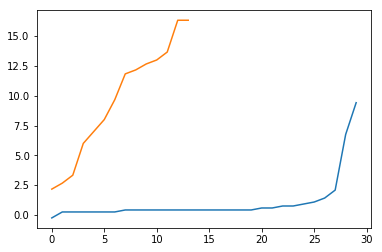

In [16]:
plt.plot(track[6])
plt.plot(track[7])

(array([3., 0., 2., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1.]),
 array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
         7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. ]),
 <a list of 20 Patch objects>)

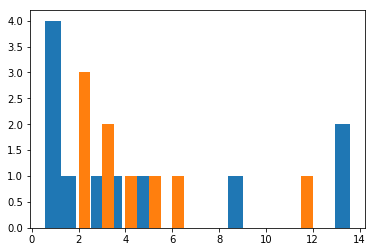

In [18]:
track = dynamics(2)
plt.hist(track[6],bins=20)
plt.hist(track[7],bins=20)

In [ ]:
alpha = np.divide(np.square(m_dur),s_dur)
alpha

In [ ]:
beta = np.divide(s_dur,m_dur)
beta